In [29]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Tue May 13 02:22:59 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   54C    P0             27W /   70W |     130MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Aplicacion modelos

In [30]:
!git clone https://github.com/rapidsai/rapidsai-csp-utils.git
!python rapidsai-csp-utils/colab/pip-install.py

fatal: destination path 'rapidsai-csp-utils' already exists and is not an empty directory.
Installing RAPIDS remaining 25.04 libraries
Using Python 3.11.12 environment at: /usr
Audited 11 packages in 144ms

        ***********************************************************************
        The pip install of RAPIDS is complete.

        Please do not run any further installation from the conda based installation methods, as they may cause issues!

        Please ensure that you're pulling from the git repo to remain updated with the latest working install scripts.

        Troubleshooting:
            - If there is an installation failure, please check back on RAPIDSAI owned templates/notebooks to see how to update your personal files.
            - If an installation failure persists when using the latest script, please make an issue on https://github.com/rapidsai-community/rapidsai-csp-utils
        ***********************************************************************
        


In [31]:
pip install ucimlrepo

In [32]:
import warnings
warnings.filterwarnings('ignore')

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo

In [34]:
covertype = fetch_ucirepo(id=31)

In [35]:
X = covertype.data.features
y = covertype.data.targets

In [36]:
X.drop(["Hillshade_9am"], axis=1, inplace=True)

In [37]:
from sklearn.model_selection import train_test_split, StratifiedKFold

In [38]:
# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [39]:
loaded_SMOTE = pd.read_csv('datos_smote.csv')
X_train_SM = loaded_SMOTE.drop('Cover_Type', axis=1)
y_train_SM = loaded_SMOTE['Cover_Type']

In [40]:
loaded_ADA = pd.read_csv('datos_ada.csv')
X_train_ADA = loaded_ADA.drop('Cover_Type', axis=1)
y_train_ADA = loaded_ADA['Cover_Type']

In [41]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc, roc_auc_score

In [42]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_test_sc = scaler.fit_transform(X_test)

In [43]:
def metricas(model, scaler = None):
    if scaler == None:
        y_pred = model.predict(X_test)
    else:
        y_pred = model.predict(scaler.fit_transform(X_test))

    # Precisión del modelo
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Precisión: {accuracy * 100:.2f}%")

    # Matriz de confusión
    print("Matriz de confusión:")
    print(confusion_matrix(y_test, y_pred))

    # Reporte de clasificación
    print("Reporte de clasificación:")
    print(classification_report(y_test, y_pred))

In [44]:
from itertools import cycle
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import RocCurveDisplay

label_binarizer = LabelBinarizer().fit(y_train)
y_onehot_test = label_binarizer.transform(y_test)

In [45]:
def LAUC_curvas(model, scaler = None, linScv = False):

    n_classes = 7

    if linScv:
        y_score = model.decision_function(X_test_sc)
    elif scaler == None:
        y_score = model.predict_proba(X_test)
    else:
        y_score = model.predict_proba(scaler.fit_transform(X_test))

    if hasattr(y_score, 'to_numpy'):
        y_score = y_score.to_numpy()

    # store the fpr, tpr, and roc_auc for all averaging strategies
    fpr, tpr, roc_auc = dict(), dict(), dict()
    # Compute micro-average ROC curve and ROC area
    fpr["micro"], tpr["micro"], _ = roc_curve(y_onehot_test.ravel(), y_score.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    print(f"Micro-averaged One-vs-Rest ROC AUC score:\n{roc_auc['micro']:.2f}")

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_onehot_test[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    fpr_grid = np.linspace(0.0, 1.0, 1000)

    # Interpolate all ROC curves at these points
    mean_tpr = np.zeros_like(fpr_grid)

    for i in range(n_classes):
        mean_tpr += np.interp(fpr_grid, fpr[i], tpr[i])  # linear interpolation

    # Average it and compute AUC
    mean_tpr /= n_classes

    fpr["macro"] = fpr_grid
    tpr["macro"] = mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

    print(f"Macro-averaged One-vs-Rest ROC AUC score:\n{roc_auc['macro']:.2f}")
    fig, ax = plt.subplots(figsize=(6, 6))


    plt.plot(
        fpr["micro"],
        tpr["micro"],
        label=f"micro-average ROC curve (AUC = {roc_auc['micro']:.2f})",
        color="deeppink",
        linestyle=":",
        linewidth=4,
    )

    plt.plot(
        fpr["macro"],
        tpr["macro"],
        label=f"macro-average ROC curve (AUC = {roc_auc['macro']:.2f})",
        color="navy",
        linestyle=":",
        linewidth=4,
    )

    colors = cycle(["aqua", "darkorange", "cornflowerblue", "lime", "olive", "navy", "maroon"])
    for class_id, color in zip(range(n_classes), colors):
        RocCurveDisplay.from_predictions(
            y_onehot_test[:, class_id],
            y_score[:, class_id],
            name=f"ROC curve for Class {class_id + 1}",
            color=color,
            ax=ax,
        )

    _ = ax.set(
        xlabel="False Positive Rate",
        ylabel="True Positive Rate",
        title="Extension of Receiver Operating Characteristic\nto One-vs-Rest multiclass",
    )

In [46]:
from sklearn.model_selection import cross_val_score, GridSearchCV

In [19]:
import matplotlib
matplotlib.rc_file_defaults()

## K Nearest Neighbors

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
clf = KNeighborsClassifier(algorithm = "kd_tree", n_jobs = -1)
pipeline = Pipeline([
    ('scaler', None),
    ('model', clf)
])
neighbors_settings = range(1, 13)
param_grid = {'model__n_neighbors': neighbors_settings}
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=StratifiedKFold(5),
    scoring='roc_auc_ovr',
    n_jobs=-1,  # Paralelizar la búsqueda
    verbose=1
)

**Dataset desbalanceado**

In [ ]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=Pipeline(steps=[('scaler', None),
                                       ('model',
                                        KNeighborsClassifier(algorithm='kd_tree',
                                                             n_jobs=-1))]),
             n_jobs=-1, param_grid={'model__n_neighbors': range(1, 13)},
             scoring='roc_auc_ovr', verbose=1)

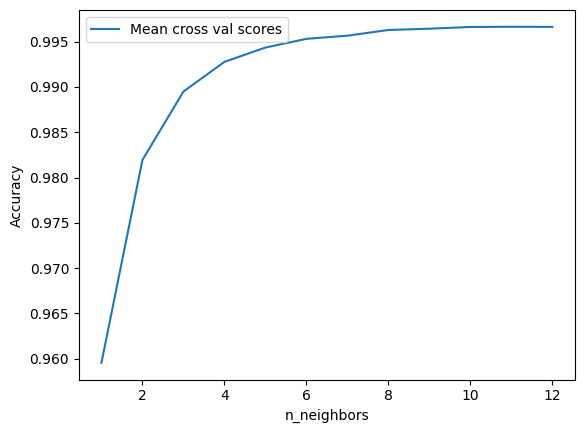

In [ ]:
results = grid_search.cv_results_
scores = results['mean_test_score']
plt.plot(neighbors_settings, scores, label="Mean cross val scores")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend()

Mejores hiperparámetros: {'model__n_neighbors': 11}
Precisión: 95.99%
Matriz de confusión:
[[40797  1629     1     0    37     5    88]
 [ 1389 54816    76     0   133    70    16]
 [    5   120  6830    17     5   144     0]
 [    0     1   102   373     0    50     0]
 [   26   230    23     0  1707     9     0]
 [    7   129   186     9     5  3153     0]
 [  124    22     0     0     1     0  3868]]
Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.96      0.96      0.96     42557
           2       0.96      0.97      0.97     56500
           3       0.95      0.96      0.95      7121
           4       0.93      0.71      0.81       526
           5       0.90      0.86      0.88      1995
           6       0.92      0.90      0.91      3489
           7       0.97      0.96      0.97      4015

    accuracy                           0.96    116203
   macro avg       0.94      0.90      0.92    116203
weighted avg       0.96  

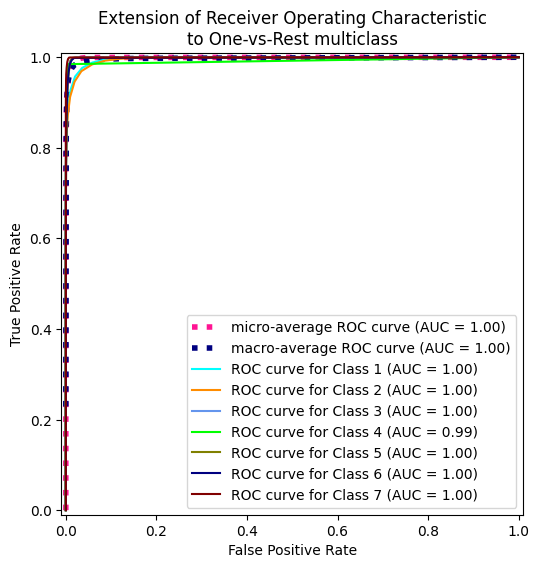

In [ ]:
print("Mejores hiperparámetros:", grid_search.best_params_)

# Evaluar el mejor modelo
best_model = grid_search.best_estimator_

metricas(best_model)
LAUC_curvas(best_model)

**Dataset balanceado con SMOTE**

In [ ]:
start = time.process_time()  # Inicia el contador de CPU time
grid_search.fit(X_train_SM, y_train_SM)
end = time.process_time()  # Finaliza el contador de CPU time
print(f"CPU Time: {end - start} segundos")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
CPU Time: 30.122877766000002 segundos


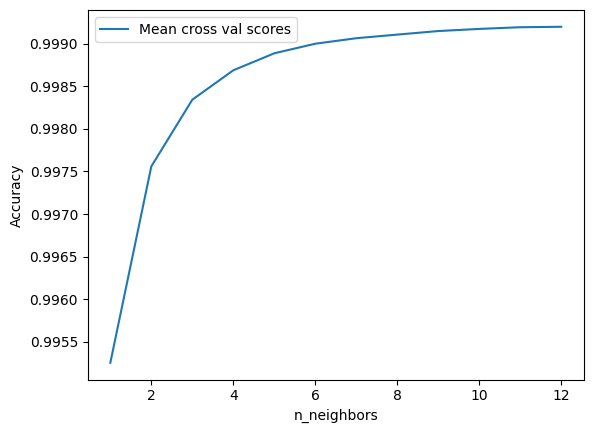

In [ ]:
results = grid_search.cv_results_
scores = results['mean_test_score']
plt.plot(neighbors_settings, scores, label="Mean cross val scores")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend()

Mejores hiperparámetros: {'model__n_neighbors': 12}
Precisión: 94.75%
Matriz de confusión:
[[41167   814     6     0   139    16   415]
 [ 2664 52224   349     2   824   353    84]
 [    0     6  6883    64    22   146     0]
 [    0     0    24   482     0    20     0]
 [    0     9     5     0  1975     5     1]
 [    0     5    67    41     7  3369     0]
 [    8     0     0     0     0     0  4007]]
Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.94      0.97      0.95     42557
           2       0.98      0.92      0.95     56500
           3       0.94      0.97      0.95      7121
           4       0.82      0.92      0.86       526
           5       0.67      0.99      0.80      1995
           6       0.86      0.97      0.91      3489
           7       0.89      1.00      0.94      4015

    accuracy                           0.95    116203
   macro avg       0.87      0.96      0.91    116203
weighted avg       0.95  

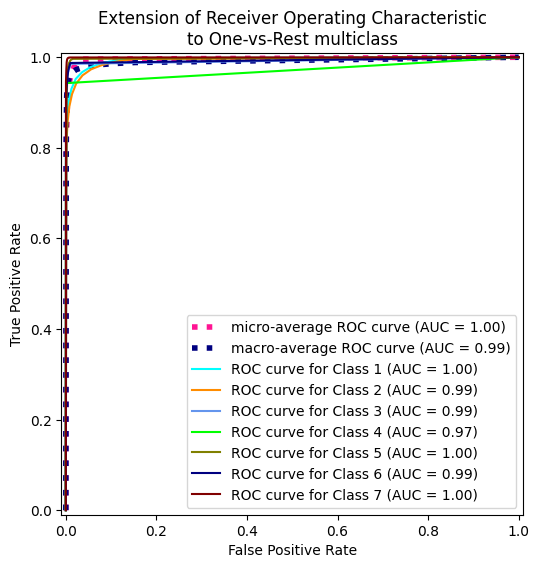

In [ ]:
print("Mejores hiperparámetros:", grid_search.best_params_)

# Evaluar el mejor modelo
best_model = grid_search.best_estimator_

metricas(best_model)
LAUC_curvas(best_model)

**Dataset balanceado con ADA**

In [ ]:
start = time.process_time()  # Inicia el contador de CPU time
grid_search.fit(X_train_ADA, y_train_ADA)
end = time.process_time()  # Finaliza el contador de CPU time
print(f"CPU Time: {end - start} segundos")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
CPU Time: 26.95348169800002 segundos


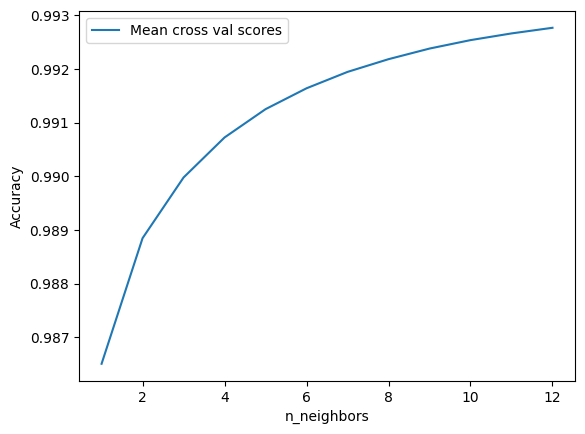

In [ ]:
results = grid_search.cv_results_
scores = results['mean_test_score']
plt.plot(neighbors_settings, scores, label="Mean cross val scores")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend()

Mejores hiperparámetros: {'model__n_neighbors': 12}
Precisión: 93.46%
Matriz de confusión:
[[41945   159     6     0    89    11   347]
 [ 4837 49911   444     2   849   363    94]
 [    1     1  6941    61    14   103     0]
 [    0     0    35   466     0    25     0]
 [    1     7     9     0  1968     9     1]
 [    0     3    83    34     7  3362     0]
 [    9     0     0     0     0     0  4006]]
Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.90      0.99      0.94     42557
           2       1.00      0.88      0.94     56500
           3       0.92      0.97      0.95      7121
           4       0.83      0.89      0.86       526
           5       0.67      0.99      0.80      1995
           6       0.87      0.96      0.91      3489
           7       0.90      1.00      0.95      4015

    accuracy                           0.93    116203
   macro avg       0.87      0.95      0.91    116203
weighted avg       0.94  

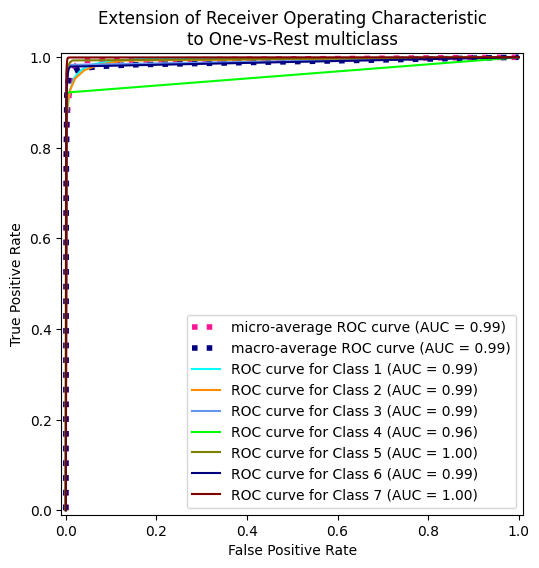

In [ ]:
print("Mejores hiperparámetros:", grid_search.best_params_)

# Evaluar el mejor modelo
best_model_ADA = grid_search.best_estimator_

metricas(best_model_ADA)
LAUC_curvas(best_model_ADA)

**Mejor modelo**

In [ ]:
knn = KNeighborsClassifier(n_neighbors = 1, algorithm = "kd_tree", n_jobs = -1)
start = time.process_time()  # Inicia el contador de CPU time
knn.fit(X_train_SM, y_train_SM)
metricas(knn)
LAUC_curvas(knn)
end = time.process_time()  # Finaliza el contador de CPU time
print(f"CPU Time: {end - start} segundos")

## Regresion Logistica

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
X_train_sc = scaler.fit_transform(X_train, y_train)

In [ ]:
print(np.logspace(-3, 3, 7))

[1.e-03 1.e-02 1.e-01 1.e+00 1.e+01 1.e+02 1.e+03]


**Dataset desbalanceado**

In [ ]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Escalado para que L2 funcione correctamente
    ('model', LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000, n_jobs = -1, multi_class = "ovr", random_state = 42))
])

param_grid = {
    'model__C': np.logspace(-3, 3, 7),  # Inverso de la fuerza de regularización
    'model__class_weight': [None]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='roc_auc_ovr',
    cv=StratifiedKFold(5),
    verbose = 1
)

In [ ]:
grid_search.fit(X_train, y_train)
print("Mejores hiperparámetros:", grid_search.best_params_)

# Evaluar el mejor modelo
best_model = grid_search.best_estimator_

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Mejores hiperparámetros: {'model__C': np.float64(1.0), 'model__class_weight': None}


Precisión: 71.56%
Matriz de confusión:
[[29436 12274    35     0     2     0   810]
 [ 9990 45001  1267     2    63   110    67]
 [    0   743  6146    66     0   166     0]
 [    0     0   336   146     0    44     0]
 [   45  1711   206     0    27     6     0]
 [    0  1250  1962    28     5   244     0]
 [ 1816    31    17     0     0     0  2151]]
Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.71      0.69      0.70     42557
           2       0.74      0.80      0.77     56500
           3       0.62      0.86      0.72      7121
           4       0.60      0.28      0.38       526
           5       0.28      0.01      0.03      1995
           6       0.43      0.07      0.12      3489
           7       0.71      0.54      0.61      4015

    accuracy                           0.72    116203
   macro avg       0.58      0.46      0.47    116203
weighted avg       0.70      0.72      0.70    116203

Micro-averaged One-vs-

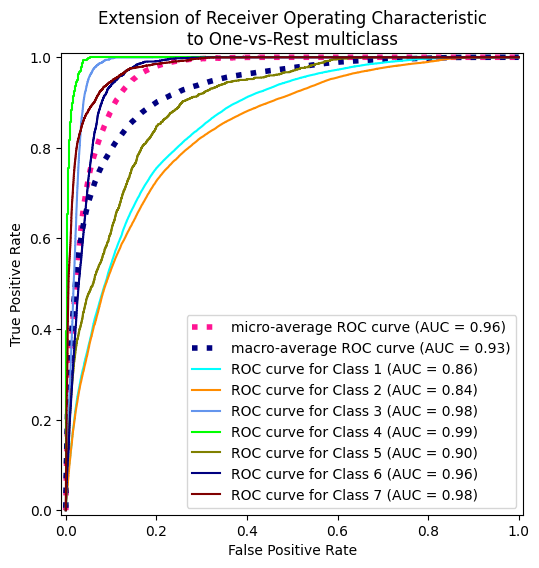

In [ ]:
metricas(best_model)
LAUC_curvas(best_model)

In [ ]:
results = grid_search.cv_results_
scores = results['mean_test_score']
print(scores)

[0.92628789 0.9296591  0.930125   0.93016565 0.93016041 0.9301623
 0.93016407]


**Class weight balanced**

In [ ]:
param_gridB = {
    'model__C': np.logspace(-3, 3, 7),  # Inverso de la fuerza de regularización
    'model__class_weight': ['balanced']
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_gridB,
    scoring='roc_auc_ovr',
    cv=StratifiedKFold(5),
    verbose = 1
)

In [ ]:
grid_search.fit(X_train, y_train)
print("Mejores hiperparámetros:", grid_search.best_params_)

# Evaluar el mejor modelo
best_model_B = grid_search.best_estimator_

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Mejores hiperparámetros: {'model__C': np.float64(1000.0), 'model__class_weight': 'balanced'}


Precisión: 64.04%
Matriz de confusión:
[[29002  8127    22     0  1030   245  4131]
 [12731 34935  1229    26  5857  1414   308]
 [    0   101  3861   441   784  1934     0]
 [    0     0   163   293     0    70     0]
 [   39   644   185     0  1061    66     0]
 [    0   195   892   132   384  1886     0]
 [  611     6    17     0     0     0  3381]]
Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.68      0.68      0.68     42557
           2       0.79      0.62      0.70     56500
           3       0.61      0.54      0.57      7121
           4       0.33      0.56      0.41       526
           5       0.12      0.53      0.19      1995
           6       0.34      0.54      0.41      3489
           7       0.43      0.84      0.57      4015

    accuracy                           0.64    116203
   macro avg       0.47      0.62      0.51    116203
weighted avg       0.70      0.64      0.66    116203

Micro-averaged One-vs-

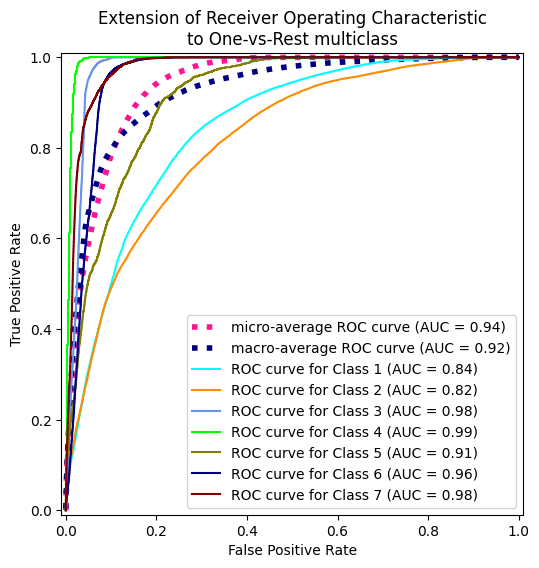

In [ ]:
metricas(best_model_B)
LAUC_curvas(best_model_B)

In [ ]:
from cuml.linear_model import LogisticRegression as cuLogisticRegression
from cuml.svm import LinearSVC as cuLinearSVC
from cuml.preprocessing import StandardScaler as cuStandardScaler

In [ ]:
import cudf
X_train_gpu = cudf.DataFrame(X_train)
y_train_gpu = cudf.DataFrame(y_train)
X_train_SM_gpu = cudf.DataFrame(X_train_SM)
y_train_SM_gpu = cudf.DataFrame(y_train_SM)

In [ ]:
# 1. Definir pipeline con cuML (GPU)
pipeline = Pipeline([
    ('scaler', cuStandardScaler()),  # Escalado en GPU
    ('model', None)  # Modelo se definirá en el grid
])

# 2. Espacio de búsqueda de hiperparámetros
param_grid = {
    # Regresión Logística L1 (GPU)
        'model': [cuLogisticRegression(penalty='l1', solver ='qn')],
        'model__C': np.logspace(-3, 3, 7),  # 0.001 a 1000
        'model__max_iter': [5000],
        'model__class_weight': ['balanced']
}


# 3. Configurar GridSearch
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='roc_auc_ovr',
    cv=5,  # Reducir CV para mayor velocidad
    n_jobs=1,  # cuML no soporta n_jobs
    verbose=2
)

# 4. Entrenamiento en GPU
print("Iniciando entrenamiento con GPU...")
grid_search.fit(X_train_gpu, y_train_gpu)

# Resultados
print(f"\nMejor modelo: {grid_search.best_params_}")
print(f"Accuracy: {grid_search.best_score_:.4f}")

Iniciando entrenamiento con GPU...
Fitting 5 folds for each of 7 candidates, totalling 35 fits
[CV] END model=LogisticRegression(), model__C=0.001, model__class_weight=balanced, model__max_iter=5000; total time=   8.2s
[CV] END model=LogisticRegression(), model__C=0.001, model__class_weight=balanced, model__max_iter=5000; total time=   7.9s
[CV] END model=LogisticRegression(), model__C=0.001, model__class_weight=balanced, model__max_iter=5000; total time=  10.2s
[CV] END model=LogisticRegression(), model__C=0.001, model__class_weight=balanced, model__max_iter=5000; total time=   9.6s
[CV] END model=LogisticRegression(), model__C=0.001, model__class_weight=balanced, model__max_iter=5000; total time=   8.7s
[CV] END model=LogisticRegression(), model__C=0.01, model__class_weight=balanced, model__max_iter=5000; total time=  17.0s
[CV] END model=LogisticRegression(), model__C=0.01, model__class_weight=balanced, model__max_iter=5000; total time=  18.7s
[CV] END model=LogisticRegression(), mo

Precisión: 72.19%
Matriz de confusión:
[[29945 11873    14     0     0     1   724]
 [10152 45292   771     2     0   244    39]
 [    0   736  6044    93     0   248     0]
 [    0     0   385    46     0    95     0]
 [   11  1917    67     0     0     0     0]
 [    0   980  1999    28     0   482     0]
 [ 1896    37     0     0     0     0  2082]]
Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.71      0.70      0.71     42557
           2       0.74      0.80      0.77     56500
           3       0.65      0.85      0.74      7121
           4       0.27      0.09      0.13       526
           5       0.00      0.00      0.00      1995
           6       0.45      0.14      0.21      3489
           7       0.73      0.52      0.61      4015

    accuracy                           0.72    116203
   macro avg       0.51      0.44      0.45    116203
weighted avg       0.70      0.72      0.71    116203

si
Micro-averaged One-

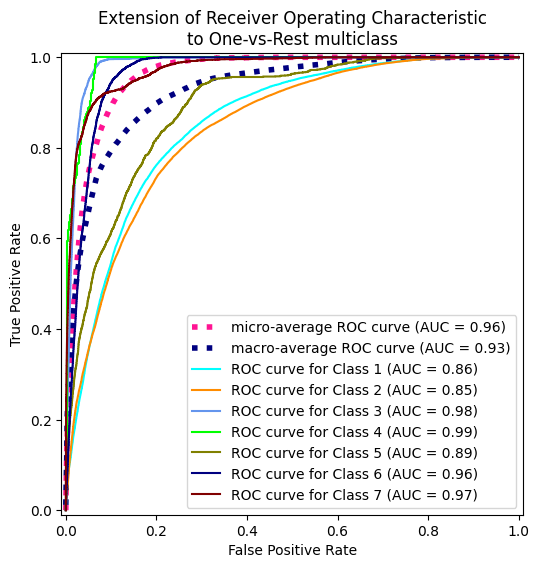

In [ ]:
best_model_l1_B = grid_search.best_estimator_
metricas(best_model_l1_B)
LAUC_curvas(best_model_l1_B)

In [ ]:
# 1. Definir pipeline con cuML (GPU)
pipeline = Pipeline([
    ('scaler', cuStandardScaler()),  # Escalado en GPU
    ('model', None)  # Modelo se definirá en el grid
])

# 2. Espacio de búsqueda de hiperparámetros
param_grid = {
    # Regresión Logística L1 (GPU)
        'model': [cuLogisticRegression(penalty='l1', solver ='qn')],
        'model__C': np.logspace(-3, 3, 7),  # 0.001 a 1000
        'model__max_iter': [1000]
}


# 3. Configurar GridSearch
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='roc_auc_ovr',
    cv=5,  # Reducir CV para mayor velocidad
    n_jobs=1,  # cuML no soporta n_jobs
    verbose=2
)

# 4. Entrenamiento en GPU
print("Iniciando entrenamiento con GPU...")
grid_search.fit(X_train_SM_gpu, y_train_SM_gpu)

# Resultados
print(f"\nMejor modelo: {grid_search.best_params_}")
print(f"Accuracy: {grid_search.best_score_:.4f}")

Iniciando entrenamiento con GPU...
Fitting 5 folds for each of 7 candidates, totalling 35 fits
[CV] END model=LogisticRegression(), model__C=0.001, model__max_iter=1000; total time= 1.1min
[CV] END model=LogisticRegression(), model__C=0.001, model__max_iter=1000; total time= 1.1min
[CV] END model=LogisticRegression(), model__C=0.001, model__max_iter=1000; total time= 1.1min
[CV] END model=LogisticRegression(), model__C=0.001, model__max_iter=1000; total time= 1.7min
[CV] END model=LogisticRegression(), model__C=0.001, model__max_iter=1000; total time= 1.4min
[2025-05-11 21:14:28.404] [CUML] [warning] QWL-QN: max iterations reached
[2025-05-11 21:14:28.404] [CUML] [warning] Maximum iterations reached before solver is converged. To increase model accuracy you can increase the number of iterations (max_iter) or improve the scaling of the input data.
[CV] END model=LogisticRegression(), model__C=0.01, model__max_iter=1000; total time= 2.9min
[2025-05-11 21:16:59.246] [CUML] [warning] QWL-Q

In [ ]:
# Modelo con regularización L1
model_l1 = LogisticRegression(
    penalty='l1',         # Tipo de regularización (L1)
    C=0.1,                # Fuerza de regularización (inverso: C=0.1 es alta regularización)
    solver='saga',        # Algoritmo compatible con L1 (otros: 'liblinear')
    max_iter=1000,        # Aumentar si no converge
    random_state=42,
    verbose=2,             # Ver progreso
    n_jobs = -1,
    multi_class= "ovr"
)
start = time.process_time()
model_l1.fit(X_train_sc, y_train)
end = time.process_time()
print(f"CPU Time: {end - start} segundos")



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


convergence after 379 epochs took 566 seconds
convergence after 960 epochs took 1359 seconds
max_iter reached after 1498 seconds
max_iter reached after 1418 seconds
max_iter reached after 1489 seconds


KeyboardInterrupt: 

In [ ]:
# Modelo con regularización L2 (configuración por defecto)
model_l2 = LogisticRegression(
    penalty='l2',         # Regularización L2 (configuración por defecto)
    C=1000,                # Valor por defecto
    solver='lbfgs',       # Algoritmo para L2 ('lbfgs', 'newton-cg', 'sag')
    max_iter=1000,
    n_jobs = -1,
    multi_class="ovr",
    verbose = 1
)
start = time.process_time()
model_l2.fit(X_train_sc, y_train)
end = time.process_time()
print(f"CPU Time: {end - start} segundos")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


CPU Time: 0.47875998399999986 segundos


[Parallel(n_jobs=-1)]: Done   7 out of   7 | elapsed:   22.4s finished


Precisión: 71.56%
Matriz de confusión:
[[29380 12328    35     0     2     0   812]
 [ 9935 45057  1267     2    62   110    67]
 [    0   740  6146    70     0   165     0]
 [    0     0   328   154     0    44     0]
 [   44  1717   206     0    26     2     0]
 [    0  1252  1959    30     4   244     0]
 [ 1817    31    17     0     0     0  2150]]
Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.71      0.69      0.70     42557
           2       0.74      0.80      0.77     56500
           3       0.62      0.86      0.72      7121
           4       0.60      0.29      0.39       526
           5       0.28      0.01      0.02      1995
           6       0.43      0.07      0.12      3489
           7       0.71      0.54      0.61      4015

    accuracy                           0.72    116203
   macro avg       0.58      0.47      0.48    116203
weighted avg       0.70      0.72      0.70    116203

Micro-averaged One-vs-

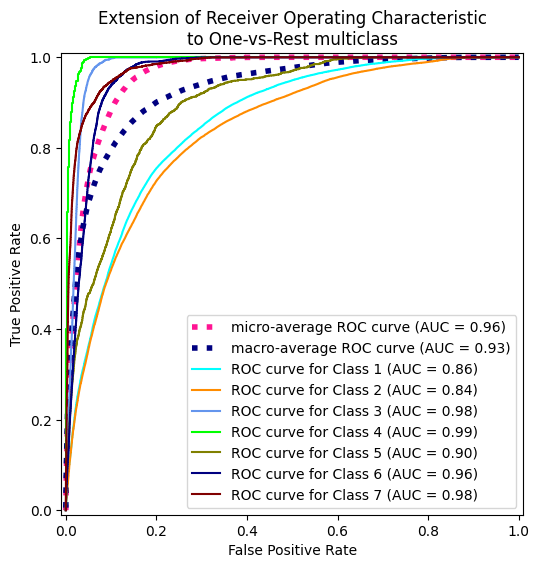

In [ ]:
metricas(model_l2, StandardScaler())
LAUC_curvas(model_l2, StandardScaler())

In [ ]:
print("Coeficientes L1:", model_l1.coef_)
print("Coeficientes L2:", model_l2.coef_)

# Contar coeficientes no nulos (L1 tiende a eliminar características)
print("Características no nulas (L1):", np.sum(model_l1.coef_ != 0))
print("Características no nulas (L2):", np.sum(model_l2.coef_ != 0))

Coeficientes L1: [[ 1.96701280e+00 -4.07914441e-02 -1.13931589e-01 -2.98984166e-01
  -9.31559168e-02 -1.48958937e-01 -5.11565740e-01  2.91434613e-01
  -1.27601363e-02  3.34722564e-01  0.00000000e+00 -4.13525245e-01
  -2.75137476e-01 -7.88759246e-02  0.00000000e+00 -1.23808043e-01
  -6.31543326e-02  2.63492003e-03  5.36810259e-02  3.96220935e-02
   3.18117835e-03 -1.33344736e-01 -1.46437781e-02 -4.60995447e-02
   0.00000000e+00  3.50128268e-02  3.05329157e-02 -8.71496838e-03
   5.59115587e-02  1.12488749e-01  1.30363900e-01  2.70391511e-01
   2.50633098e-01  1.15389339e-01 -2.26345386e-02 -6.41514896e-03
   3.97429342e-02 -1.87691467e-02 -6.17643697e-02 -6.74538516e-02
   1.15054864e-01  2.48709939e-02  1.36214659e-01 -8.13320058e-02
  -9.09263403e-02 -2.99139034e-02 -2.17180650e-01 -1.57957083e-01
  -1.52532094e-01 -1.88770425e-01 -8.10714479e-02  1.83186707e-02
  -7.11673899e-01]
 [-1.54724016e+00 -3.59526531e-02  1.15343013e-01  3.26397032e-01
   2.80059954e-02  1.29458889e-01  4.998

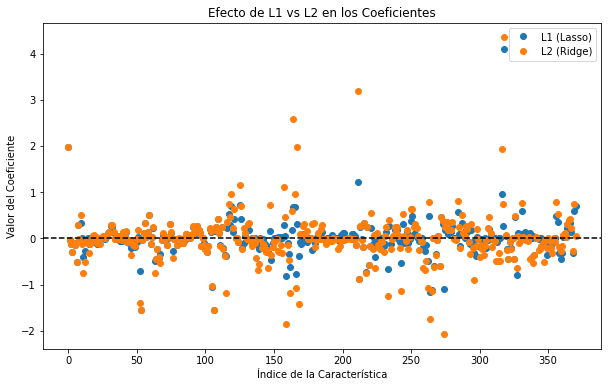

In [ ]:
# Coeficientes L1 vs L2
plt.figure(figsize=(10, 6))
plt.plot(model_l1.coef_.flatten(), 'o', label='L1 (Lasso)')
plt.plot(model_l2.coef_.flatten(), 'o', label='L2 (Ridge)')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel("Índice de la Característica")
plt.ylabel("Valor del Coeficiente")
plt.legend()
plt.title("Efecto de L1 vs L2 en los Coeficientes")
plt.show()

## Bayesiano

In [ ]:
from sklearn.naive_bayes import MultinomialNB, BernoulliNB, GaussianNB
from sklearn.preprocessing import MinMaxScaler

In [ ]:
pipeline = Pipeline([
    ('scaler', None),  # Placeholder para el escalador (se definirá en el grid)
    ('clf', None)      # Placeholder para el clasificador
])

In [ ]:
param_gridG = [
    # Opción 1: GaussianNB (para características continuas)
    {
        'scaler': [StandardScaler(), MinMaxScaler(), None],
        'clf': [GaussianNB()],
        'clf__var_smoothing': np.logspace(0, -9, num=10)
    }
]
# Opción 2: MultinomialNB (para conteos/frecuencias)
param_gridM = [
    {
        'scaler': [MinMaxScaler()],  # Necesario para valores negativos
        'clf': [MultinomialNB()],
        'clf__alpha': [0.1, 0.5, 1.0, 2.0],
        'clf__fit_prior': [True, False]
    }
]
param_gridB = [
    # Opción 3: BernoulliNB (para características binarias)
    {
        'scaler': [None],  # No necesita escalado
        'clf': [BernoulliNB()],
        'clf__alpha': [0.1, 0.5, 1.0, 2.0],
        'clf__fit_prior': [True, False],
        'clf__binarize': [None, 0.0, 0.5]
    }
]

In [ ]:
grid_searchG = GridSearchCV(
    estimator=pipeline,
    param_grid=param_gridG,
    cv=StratifiedKFold(5),
    scoring='roc_auc_ovr',
    verbose=1,
    refit=True          # Reentrena el mejor modelo encontrado
)

grid_searchM = GridSearchCV(
    estimator=pipeline,
    param_grid=param_gridM,
    cv=StratifiedKFold(5),
    scoring='roc_auc_ovr',
    verbose=1,
    refit=True          # Reentrena el mejor modelo encontrado
)

grid_searchB = GridSearchCV(
    estimator=pipeline,
    param_grid=param_gridB,
    cv=StratifiedKFold(5),
    scoring='roc_auc_ovr',
    verbose=1,
    refit=True          # Reentrena el mejor modelo encontrado
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
CPU Time: 114.66441488300006 segundos
Mejores hiperparámetros: {'clf': GaussianNB(), 'clf__var_smoothing': 1e-07, 'scaler': None}
Precisión: 65.21%
Matriz de confusión:
[[28485 10486    67     0   424    88  3007]
 [12941 38200  1543     3  1709  1176   928]
 [    0   949  4865   374    22   911     0]
 [    0     0   157   314     0    55     0]
 [   19  1384    39     0   487    66     0]
 [    0   529  1508    78    30  1344     0]
 [ 1909    17     8     0     3     0  2078]]
Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.66      0.67      0.66     42557
           2       0.74      0.68      0.71     56500
           3       0.59      0.68      0.64      7121
           4       0.41      0.60      0.48       526
           5       0.18      0.24      0.21      1995
           6       0.37      0.39      0.38      3489
           7       0.35      0.52      0.41     

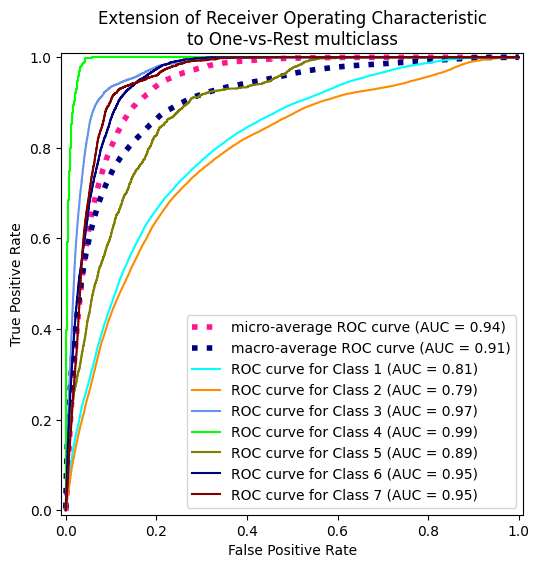

In [ ]:
start = time.process_time()  # Inicia el contador de CPU time
grid_searchG.fit(X_train, y_train)
end = time.process_time()  # Finaliza el contador de CPU time
print(f"CPU Time: {end - start} segundos")

print("Mejores hiperparámetros:", grid_searchG.best_params_)

best_model = grid_searchG.best_estimator_

metricas(best_model)
LAUC_curvas(best_model)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
CPU Time: 365.49020038699985 segundos
Mejores hiperparámetros: {'clf': GaussianNB(), 'clf__var_smoothing': 1e-08, 'scaler': None}
Precisión: 49.95%
Matriz de confusión:
[[30037  3986    43     0  2839   176  5476]
 [22184 16938  1709    86 12674  1812  1097]
 [    0    28  4245  1373   297  1178     0]
 [    0     0    62   420     0    44     0]
 [  161   181   197     0  1388    68     0]
 [   34    63  1033   401   272  1686     0]
 [  625    18    14     0    28     0  3330]]
Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.57      0.71      0.63     42557
           2       0.80      0.30      0.44     56500
           3       0.58      0.60      0.59      7121
           4       0.18      0.80      0.30       526
           5       0.08      0.70      0.14      1995
           6       0.34      0.48      0.40      3489
           7       0.34      0.83      0.48     

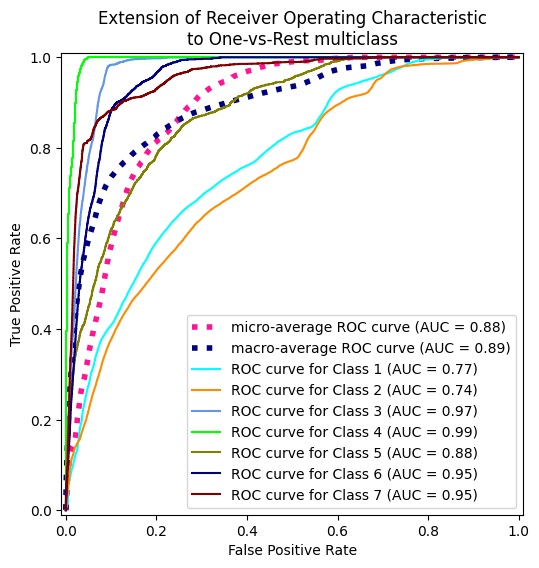

In [ ]:
start = time.process_time()  # Inicia el contador de CPU time
grid_searchG.fit(X_train_SM, y_train_SM)
end = time.process_time()  # Finaliza el contador de CPU time
print(f"CPU Time: {end - start} segundos")

print("Mejores hiperparámetros:", grid_searchG.best_params_)

best_model = grid_searchG.best_estimator_

metricas(best_model)
LAUC_curvas(best_model)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
CPU Time: 357.4205450500001 segundos
Mejores hiperparámetros: {'clf': GaussianNB(), 'clf__var_smoothing': 1e-08, 'scaler': None}
Precisión: 46.99%
Matriz de confusión:
[[27887  3464   138     0  2485   325  8258]
 [22216 15745  2852   253 11843   934  2657]
 [    0     4  5054  1716   158   189     0]
 [    0     0   172   354     0     0     0]
 [  189   143   249     0  1350    64     0]
 [   28     9  1615   790   337   710     0]
 [  463    27    17     0     2     0  3506]]
Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.55      0.66      0.60     42557
           2       0.81      0.28      0.41     56500
           3       0.50      0.71      0.59      7121
           4       0.11      0.67      0.19       526
           5       0.08      0.68      0.15      1995
           6       0.32      0.20      0.25      3489
           7       0.24      0.87      0.38      

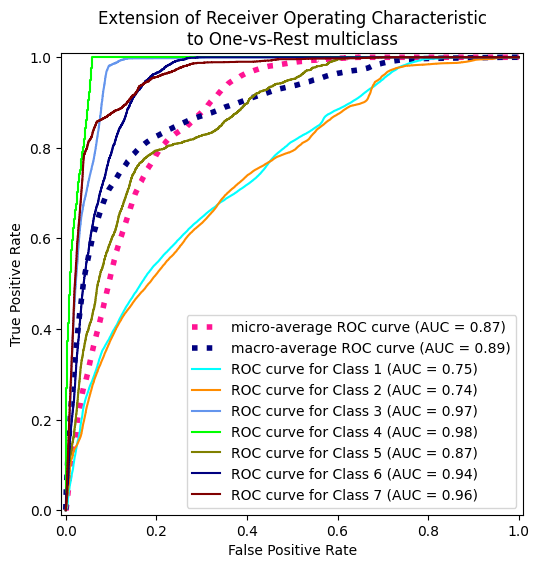

In [ ]:
start = time.process_time()  # Inicia el contador de CPU time
grid_searchG.fit(X_train_ADA, y_train_ADA)
end = time.process_time()  # Finaliza el contador de CPU time
print(f"CPU Time: {end - start} segundos")

print("Mejores hiperparámetros:", grid_searchG.best_params_)

best_model = grid_searchG.best_estimator_

metricas(best_model)
LAUC_curvas(best_model)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
CPU Time: 55.94424782299984 segundos
Mejores hiperparámetros: {'clf': MultinomialNB(), 'clf__alpha': 0.1, 'clf__fit_prior': True, 'scaler': MinMaxScaler()}
Precisión: 64.06%
Matriz de confusión:
[[19791 21730    60     0     0     0   976]
 [ 8638 45623  2101     0    31     9    98]
 [    0   437  6585    57     0    42     0]
 [    0     0   404    79     0    43     0]
 [  179  1587   229     0     0     0     0]
 [   34   837  2487     9     6   116     0]
 [ 1226   531    17     0     0     0  2241]]
Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.66      0.47      0.55     42557
           2       0.64      0.81      0.72     56500
           3       0.55      0.92      0.69      7121
           4       0.54      0.15      0.24       526
           5       0.00      0.00      0.00      1995
           6       0.55      0.03      0.06      3489
           7       0.68 

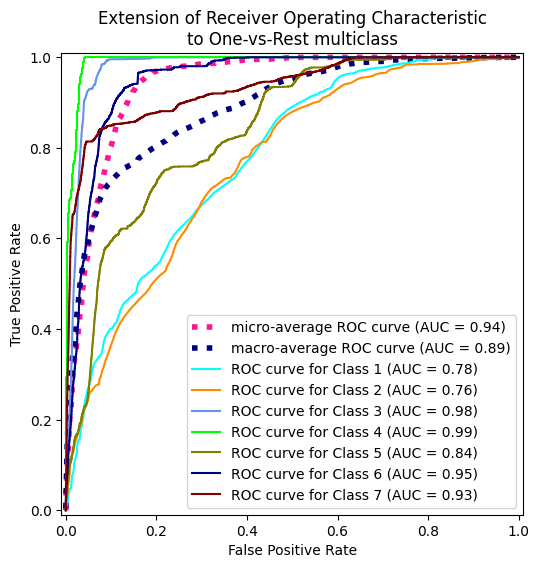

In [ ]:
start = time.process_time()  # Inicia el contador de CPU time
grid_searchM.fit(X_train, y_train)
end = time.process_time()  # Finaliza el contador de CPU time
print(f"CPU Time: {end - start} segundos")

print("Mejores hiperparámetros:", grid_searchM.best_params_)

best_model = grid_searchM.best_estimator_

metricas(best_model)
LAUC_curvas(best_model)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
CPU Time: 107.61551072099996 segundos
Mejores hiperparámetros: {'clf': MultinomialNB(), 'clf__alpha': 0.1, 'clf__fit_prior': True, 'scaler': MinMaxScaler()}
Precisión: 51.63%
Matriz de confusión:
[[18584 17024    35     0  2204   189  4521]
 [11122 32082  1040   196  9552  2188   320]
 [    0    31  2717  1600   289  2484     0]
 [    0     0    61   405     0    60     0]
 [  244   452   206     0  1034    59     0]
 [   56   201   519   494   290  1929     0]
 [  267   443    17     0    43     0  3245]]
Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.61      0.44      0.51     42557
           2       0.64      0.57      0.60     56500
           3       0.59      0.38      0.46      7121
           4       0.15      0.77      0.25       526
           5       0.08      0.52      0.13      1995
           6       0.28      0.55      0.37      3489
           7       0.40

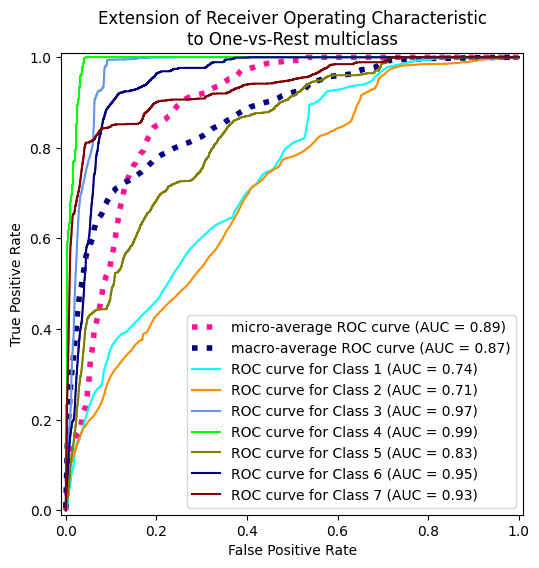

In [ ]:
start = time.process_time()  # Inicia el contador de CPU time
grid_searchM.fit(X_train_SM, y_train_SM)
end = time.process_time()  # Finaliza el contador de CPU time
print(f"CPU Time: {end - start} segundos")

print("Mejores hiperparámetros:", grid_searchM.best_params_)

best_model = grid_searchM.best_estimator_

metricas(best_model)
LAUC_curvas(best_model)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
CPU Time: 104.61894024599997 segundos
Mejores hiperparámetros: {'clf': MultinomialNB(), 'clf__alpha': 0.5, 'clf__fit_prior': True, 'scaler': MinMaxScaler()}
Precisión: 43.64%
Matriz de confusión:
[[16519 10324    35     0  7603   470  7606]
 [ 9199 24137  1078   204 15980  2330  3572]
 [    0    25  3300  1877   263  1653     3]
 [    0     0    70   422     0    34     0]
 [  168   320   206     0  1203    80    18]
 [   34    44   715   636   347  1712     1]
 [  210   176    17     0   197     0  3415]]
Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.63      0.39      0.48     42557
           2       0.69      0.43      0.53     56500
           3       0.61      0.46      0.53      7121
           4       0.13      0.80      0.23       526
           5       0.05      0.60      0.09      1995
           6       0.27      0.49      0.35      3489
           7       0.23

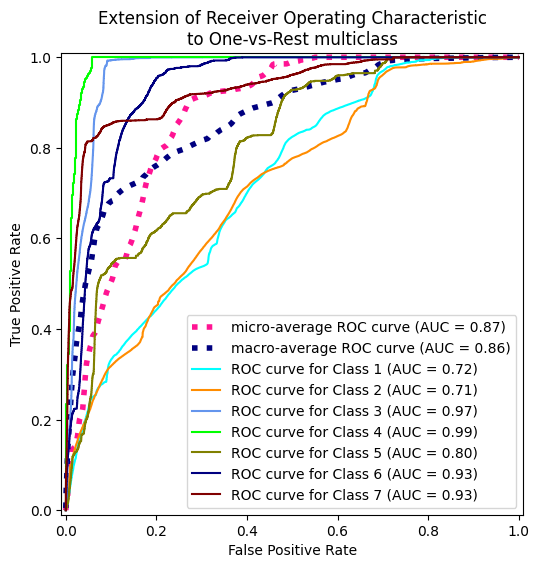

In [ ]:
start = time.process_time()  # Inicia el contador de CPU time
grid_searchM.fit(X_train_ADA, y_train_ADA)
end = time.process_time()  # Finaliza el contador de CPU time
print(f"CPU Time: {end - start} segundos")

print("Mejores hiperparámetros:", grid_searchM.best_params_)

best_model = grid_searchM.best_estimator_

metricas(best_model)
LAUC_curvas(best_model)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
CPU Time: 190.485266573 segundos
Mejores hiperparámetros: {'clf': BernoulliNB(), 'clf__alpha': 0.1, 'clf__binarize': 0.0, 'clf__fit_prior': True, 'scaler': None}
Precisión: 63.04%
Matriz de confusión:
[[20357 20717    35     0    41   188  1219]
 [ 9594 43073  1554    11   218  1829   221]
 [    0   287  6216   129    48   441     0]
 [    0     0   273   224     0    29     0]
 [  207  1409   202     0   114    63     0]
 [   70   384  2057    53   121   804     0]
 [ 1018   509    17     0     0     0  2471]]
Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.65      0.48      0.55     42557
           2       0.65      0.76      0.70     56500
           3       0.60      0.87      0.71      7121
           4       0.54      0.43      0.48       526
           5       0.21      0.06      0.09      1995
           6       0.24      0.23      0.23      3489
           7    

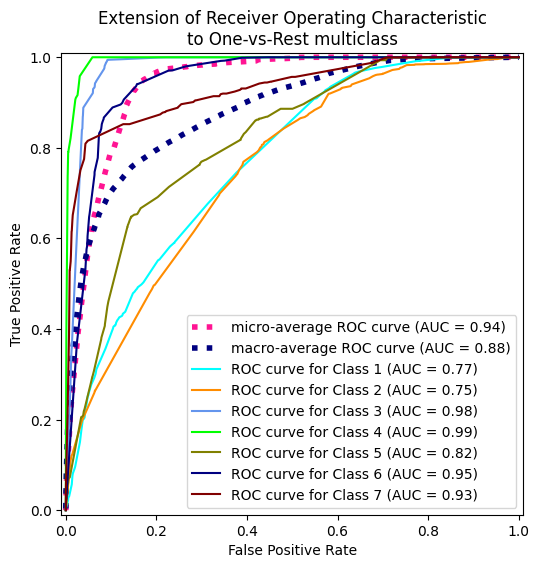

In [ ]:
start = time.process_time()  # Inicia el contador de CPU time
grid_searchB.fit(X_train, y_train)
end = time.process_time()  # Finaliza el contador de CPU time
print(f"CPU Time: {end - start} segundos")

print("Mejores hiperparámetros:", grid_searchB.best_params_)

best_model = grid_searchB.best_estimator_

metricas(best_model)
LAUC_curvas(best_model)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
CPU Time: 484.7864293700002 segundos
Mejores hiperparámetros: {'clf': BernoulliNB(), 'clf__alpha': 0.1, 'clf__binarize': 0.0, 'clf__fit_prior': False, 'scaler': None}
Precisión: 49.03%
Matriz de confusión:
[[17492 15830    32     0  4485   189  4529]
 [10278 30024  1030   217 12160  2165   626]
 [    1    31  2819  1687   325  2258     0]
 [    0     0    25   477     0    24     0]
 [  217   411   200     0  1097    63     7]
 [   75   161   593   518   337  1804     1]
 [  241   396    17     0   104     0  3257]]
Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.62      0.41      0.49     42557
           2       0.64      0.53      0.58     56500
           3       0.60      0.40      0.48      7121
           4       0.16      0.91      0.28       526
           5       0.06      0.55      0.11      1995
           6       0.28      0.52      0.36      3489
           

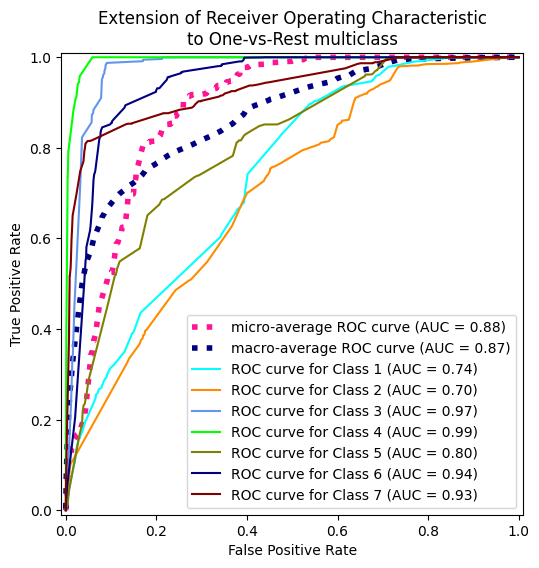

In [ ]:
start = time.process_time()  # Inicia el contador de CPU time
grid_searchB.fit(X_train_SM, y_train_SM)
end = time.process_time()  # Finaliza el contador de CPU time
print(f"CPU Time: {end - start} segundos")

print("Mejores hiperparámetros:", grid_searchB.best_params_)

best_model = grid_searchB.best_estimator_

metricas(best_model)
LAUC_curvas(best_model)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
CPU Time: 479.9803478519998 segundos
Mejores hiperparámetros: {'clf': BernoulliNB(), 'clf__alpha': 0.1, 'clf__binarize': 0.0, 'clf__fit_prior': False, 'scaler': None}
Precisión: 42.03%
Matriz de confusión:
[[14259 10248    32     0  7508   523  9987]
 [ 7812 23644  1504    47 14487  2171  6835]
 [    0     1  5461   912   263   457    27]
 [    0     0   254   272     0     0     0]
 [  129   592   192     0   849   139    94]
 [    5     0  1745   406   340   922    71]
 [  167   206    17     0   195     0  3430]]
Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.64      0.34      0.44     42557
           2       0.68      0.42      0.52     56500
           3       0.59      0.77      0.67      7121
           4       0.17      0.52      0.25       526
           5       0.04      0.43      0.07      1995
           6       0.22      0.26      0.24      3489
           

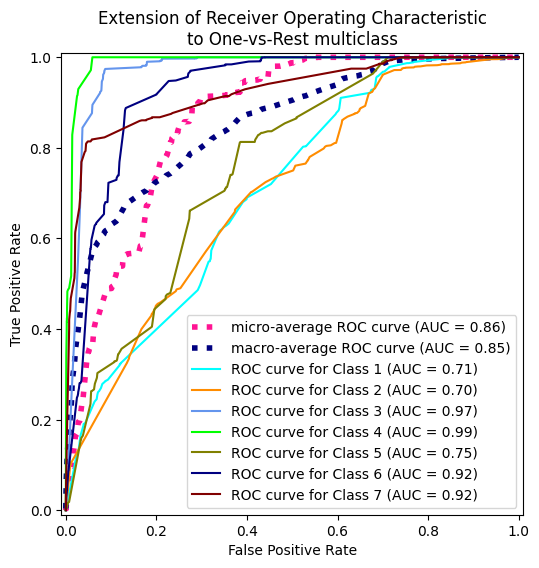

In [ ]:
start = time.process_time()  # Inicia el contador de CPU time
grid_searchB.fit(X_train_ADA, y_train_ADA)
end = time.process_time()  # Finaliza el contador de CPU time
print(f"CPU Time: {end - start} segundos")

print("Mejores hiperparámetros:", grid_searchB.best_params_)

best_model = grid_searchB.best_estimator_

metricas(best_model)
LAUC_curvas(best_model)


In [ ]:
decision_scores = model.decision_function(X_test)

# Calcular FPR, TPR y AUC para cada clase
n_classes = len(model.classes_)
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test == i, decision_scores[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    print(f'AUC para la clase {i}: {roc_auc[i]:.2f}')

# Graficar las curvas ROC
plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green']

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'Clase {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], color='black', linestyle='--', lw=2)
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC multiclase (One-vs-Rest) usando decision_function')
plt.legend(loc='lower right')
plt.show()

## Arbol de decision

In [36]:
from sklearn.tree import DecisionTreeClassifier


In [ ]:
pipeline = Pipeline([
    ('scaler', None),
    ('model', DecisionTreeClassifier(random_state = 42))
])
param_grid = {
    "model__max_depth": [10, 20, 30, None],
    "model__criterion": ["gini", "entropy"],
    "model__max_features": ["sqrt", "log2", None],
}
# Configurar Grid Search
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="roc_auc_ovr",  # Métrica de evaluación
    cv=StratifiedKFold(5),  # Validación cruzada de 5 folds
    n_jobs=-1,  # Usar todos los núcleos de la CPU
    verbose=1
)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
CPU Time: 8.313750504999916 segundos
Mejores hiperparámetros: {'model__criterion': 'gini', 'model__max_depth': 20, 'model__max_features': None}
Precisión: 90.56%
Matriz de confusión:
[[38017  4316     1     0    38     6   179]
 [ 3198 52776   136     0   191   174    25]
 [    5   270  6300    45    11   489     1]
 [    0     1    77   421     0    27     0]
 [   47   713    18     0  1205    12     0]
 [    8   303   348    23     5  2802     0]
 [  278    26     0     0     0     0  3711]]
Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.91      0.89      0.90     42557
           2       0.90      0.93      0.92     56500
           3       0.92      0.88      0.90      7121
           4       0.86      0.80      0.83       526
           5       0.83      0.60      0.70      1995
           6       0.80      0.80      0.80      3489
           7       0.95      0.92 

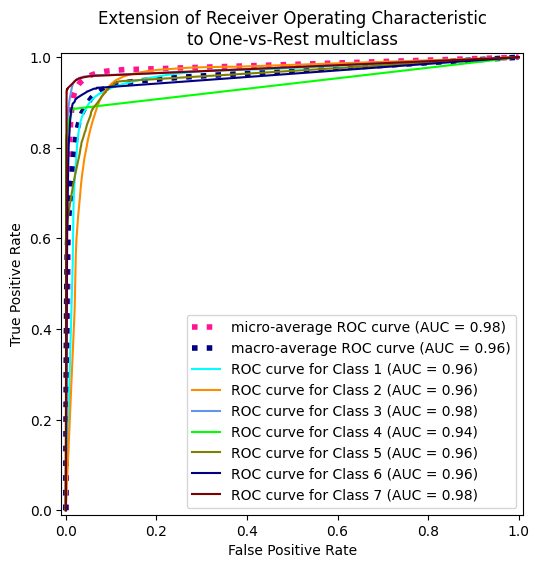

In [ ]:
start = time.process_time()  # Inicia el contador de CPU time
# Ejecutar Grid Search
grid_search.fit(X_train, y_train)
end = time.process_time()  # Finaliza el contador de CPU time
print(f"CPU Time: {end - start} segundos")

# Mejores hiperparámetros
print("Mejores hiperparámetros:", grid_search.best_params_)

# Evaluar el mejor modelo
best_model = grid_search.best_estimator_

metricas(best_model)
LAUC_curvas(best_model)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
CPU Time: 25.864894435000224 segundos
Mejores hiperparámetros: {'model__criterion': 'entropy', 'model__max_depth': 20, 'model__max_features': None}
Precisión: 91.31%
Matriz de confusión:
[[39152  2750     7     0   138    17   493]
 [ 3703 50962   246     1  1228   320    40]
 [    1    76  6620    56    21   347     0]
 [    0     1    52   456     0    17     0]
 [   18   125    17     0  1829     6     0]
 [    2    74   181    23    13  3196     0]
 [  109    17     0     0     1     0  3888]]
Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.91      0.92      0.92     42557
           2       0.94      0.90      0.92     56500
           3       0.93      0.93      0.93      7121
           4       0.85      0.87      0.86       526
           5       0.57      0.92      0.70      1995
           6       0.82      0.92      0.86      3489
           7       0.88      0

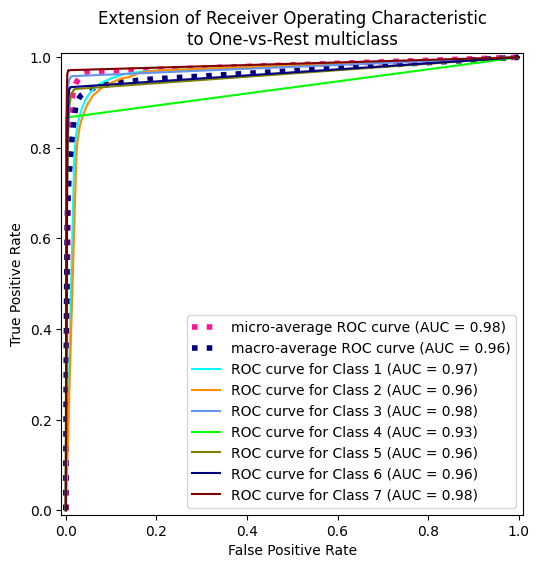

In [ ]:
start = time.process_time()  # Inicia el contador de CPU time
# Ejecutar Grid Search
grid_search.fit(X_train_SM, y_train_SM)
end = time.process_time()  # Finaliza el contador de CPU time
print(f"CPU Time: {end - start} segundos")

# Mejores hiperparámetros
print("Mejores hiperparámetros:", grid_search.best_params_)

# Evaluar el mejor modelo
best_model_SM = grid_search.best_estimator_

metricas(best_model_SM)
LAUC_curvas(best_model_SM)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
CPU Time: 22.23951835700018 segundos
Mejores hiperparámetros: {'model__criterion': 'entropy', 'model__max_depth': 20, 'model__max_features': None}
Precisión: 88.85%
Matriz de confusión:
[[38655  2701     8     0   136     7  1050]
 [ 5739 48955   264     1  1049   357   135]
 [    4   108  6446    54    38   471     0]
 [    0     0    77   434     0    15     0]
 [   23   128    16     0  1815    13     0]
 [    7    81   325    35     6  3035     0]
 [   90    19     0     0     0     0  3906]]
Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.87      0.91      0.89     42557
           2       0.94      0.87      0.90     56500
           3       0.90      0.91      0.90      7121
           4       0.83      0.83      0.83       526
           5       0.60      0.91      0.72      1995
           6       0.78      0.87      0.82      3489
           7       0.77      0.

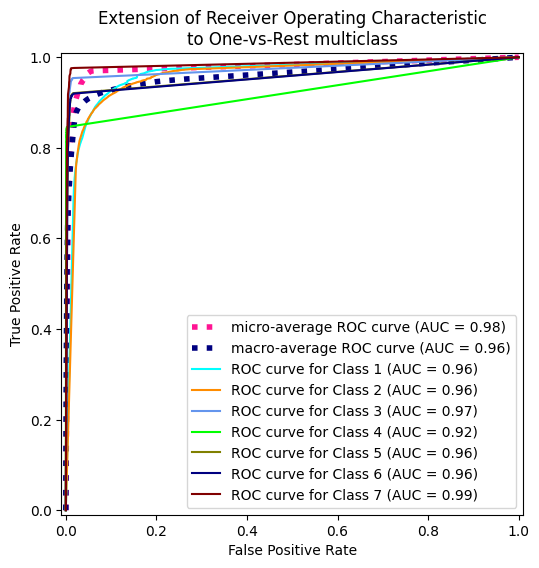

In [ ]:
start = time.process_time()  # Inicia el contador de CPU time
# Ejecutar Grid Search
grid_search.fit(X_train_ADA, y_train_ADA)
end = time.process_time()  # Finaliza el contador de CPU time
print(f"CPU Time: {end - start} segundos")

# Mejores hiperparámetros
print("Mejores hiperparámetros:", grid_search.best_params_)

# Evaluar el mejor modelo
best_model_ADA = grid_search.best_estimator_

metricas(best_model_ADA)
LAUC_curvas(best_model_ADA)

Ahora hagamos la validacion cruzada anidada usando class = 'balanced'

Fitting 5 folds for each of 24 candidates, totalling 120 fits
CPU Time: 8.525061066000035 segundos
Mejores hiperparámetros: {'model__criterion': 'gini', 'model__max_depth': 20, 'model__max_features': None}
Precisión: 87.75%
Matriz de confusión:
[[37960  3390     7     0   464    34   702]
 [ 4547 48269   328     0  2627   616   113]
 [    4   111  6473    66    45   422     0]
 [    0     0    66   438     0    22     0]
 [   23   100    17     0  1846     9     0]
 [    6    59   247    25    14  3138     0]
 [  147    27     0     0     1     0  3840]]
Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.89      0.89      0.89     42557
           2       0.93      0.85      0.89     56500
           3       0.91      0.91      0.91      7121
           4       0.83      0.83      0.83       526
           5       0.37      0.93      0.53      1995
           6       0.74      0.90      0.81      3489
           7       0.82      0.96 

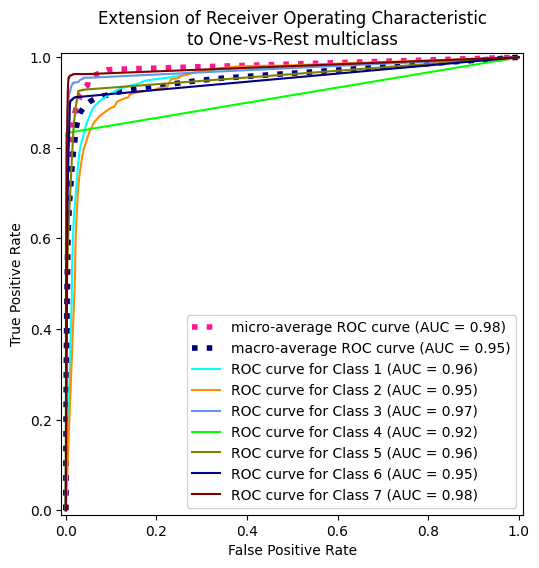

In [ ]:
pipeline_B= Pipeline([
    ('scaler', None),
    ('model', DecisionTreeClassifier(random_state = 42, class_weight="balanced"))
])

# Configurar Grid Search
grid_search = GridSearchCV(
    estimator=pipeline_B,
    param_grid=param_grid,
    scoring="roc_auc_ovr",  # Métrica de evaluación
    cv=StratifiedKFold(5),  # Validación cruzada de 5 folds
    n_jobs=-1,  # Usar todos los núcleos de la CPU
    verbose=1
)

start = time.process_time()  # Inicia el contador de CPU time
# Ejecutar Grid Search
grid_search.fit(X_train, y_train)
end = time.process_time()  # Finaliza el contador de CPU time
print(f"CPU Time: {end - start} segundos")

# Mejores hiperparámetros
print("Mejores hiperparámetros:", grid_search.best_params_)

# Evaluar el mejor modelo
best_model_B = grid_search.best_estimator_

metricas(best_model_B)
LAUC_curvas(best_model_B)

Ahora comparamos los mejores modelos de los grid search en cada metodo de balanceo

In [ ]:
print("Accuracy on test set: {:.3f}".format(best_model.score(X_test, y_test)))
print("Accuracy on test set: {:.3f}".format(best_model_B.score(X_test, y_test)))
print("Accuracy on test set: {:.3f}".format(best_model_SM.score(X_test, y_test)))
print("Accuracy on test set: {:.3f}".format(best_model_ADA.score(X_test, y_test)))

LAUC_curvas(best_model, draw = False)
LAUC_curvas(best_model_B, draw = False)
LAUC_curvas(best_model_SM, draw = False)
LAUC_curvas(best_model_ADA, draw = False)

Accuracy on test set: 0.906
Accuracy on test set: 0.877
Accuracy on test set: 0.913
Accuracy on test set: 0.888


NameError: name 'AUC_curvas' is not defined

In [38]:
tree = DecisionTreeClassifier(random_state = 42, criterion="entropy", max_depth=20, max_features = None)

start = time.process_time()  # Inicia el contador de CPU time
tree.fit(X_train_SM, y_train_SM)
end = time.process_time()  # Finaliza el contador de CPU time
print("Accuracy on training set: {:.3f}".format(tree.score(X_train_SM, y_train_SM)))
print("Accuracy on test set: {:.3f}".format(tree.score(X_test, y_test)))

print(f"CPU Time: {end - start} segundos")

Accuracy on training set: 0.979
Accuracy on test set: 0.913
CPU Time: 22.93443523299902 segundos


In [30]:
def plot_feature_importances(model):
    n_features = 53
    plt.figure(figsize=(10, 12))

    plt.barh(range(n_features), model.feature_importances_, align='center')
    plt.yticks(np.arange(n_features), X.columns, fontsize=9)
    plt.xlabel("Feature importance")
    plt.ylabel("Feature")

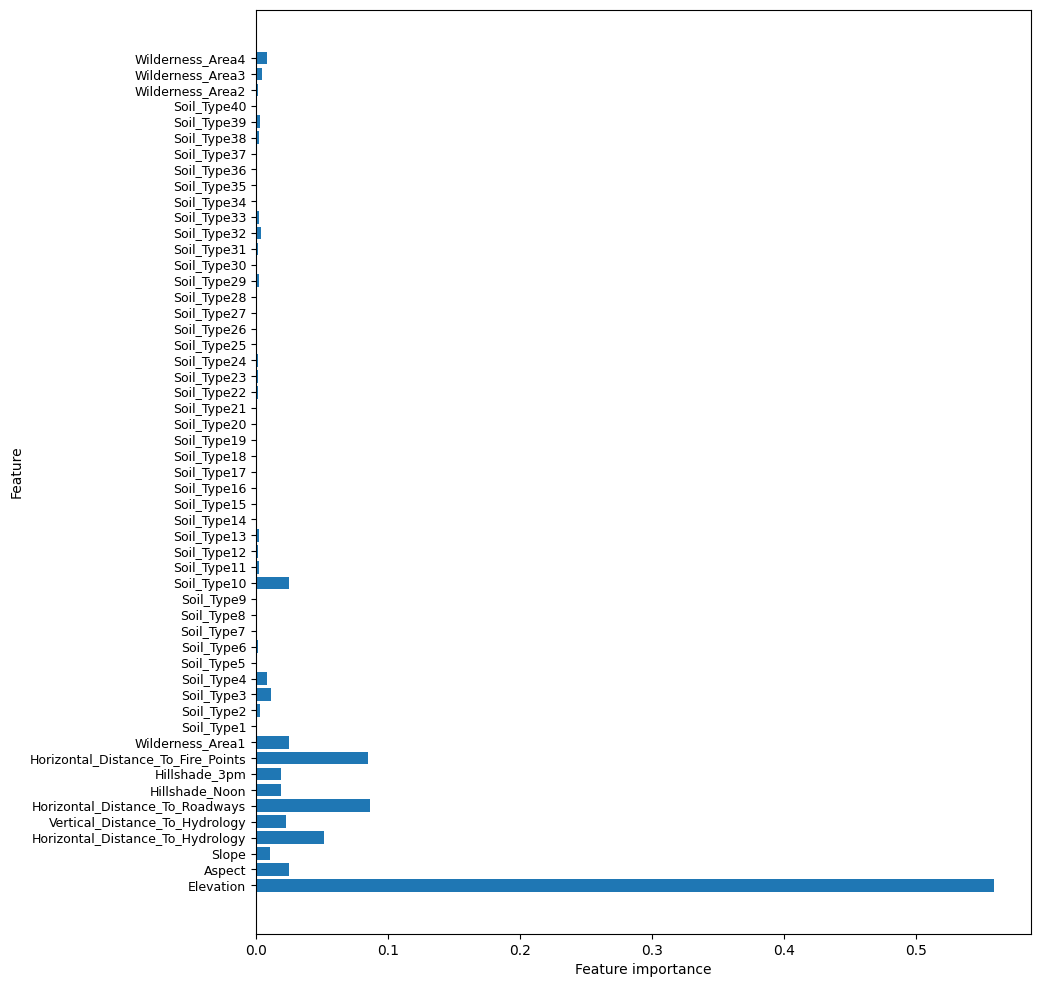

In [39]:
plot_feature_importances(tree)

## Random Forest

In [20]:
from sklearn.ensemble import RandomForestClassifier

In [22]:
rTree = RandomForestClassifier(random_state = 42, n_jobs = -1)
pipeline = Pipeline([
    ('scaler', None),
    ('model', rTree)
])
param_grid = {
    "model__n_estimators" : [50, 100],
    "model__criterion" : ["gini", "entropy"],
    "model__max_depth" : [10, 20, 30]
}
# Configurar Grid Search
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="roc_auc_ovr",  # Métrica de evaluación
    cv=StratifiedKFold(5),  # Validación cruzada de 5 folds
    verbose=1
)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
CPU Time: 4550.147939477 segundos
Mejores hiperparámetros: {'model__criterion': 'entropy', 'model__max_depth': 30, 'model__n_estimators': 100}
Precisión: 95.59%
Matriz de confusión:
[[40050  2407     1     0    10     2    87]
 [ 1147 55110    91     0    81    55    16]
 [    1    85  6892    21     4   118     0]
 [    0     0    62   450     0    14     0]
 [   24   361    15     0  1584    11     0]
 [    1    99   208    17     3  3161     0]
 [  158    24     0     0     1     0  3832]]
Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.97      0.94      0.95     42557
           2       0.95      0.98      0.96     56500
           3       0.95      0.97      0.96      7121
           4       0.92      0.86      0.89       526
           5       0.94      0.79      0.86      1995
           6       0.94      0.91      0.92      3489
           7       0.97      0.95   

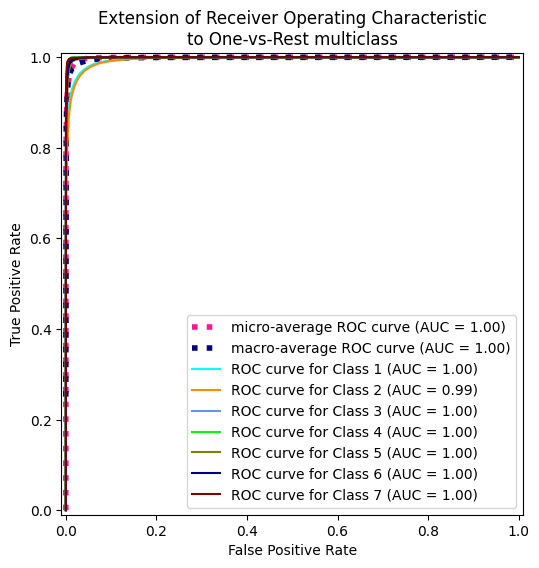

In [23]:
start = time.process_time()  # Inicia el contador de CPU time
# Ejecutar Grid Search
grid_search.fit(X_train, y_train)
end = time.process_time()  # Finaliza el contador de CPU time
print(f"CPU Time: {end - start} segundos")

# Mejores hiperparámetros
print("Mejores hiperparámetros:", grid_search.best_params_)

best_model = grid_search.best_estimator_

metricas(best_model)
LAUC_curvas(best_model)

In [ ]:
start = time.process_time()  # Inicia el contador de CPU time
# Ejecutar Grid Search
grid_search.fit(X_train_SM, y_train_SM)
end = time.process_time()  # Finaliza el contador de CPU time
print(f"CPU Time: {end - start} segundos")

# Mejores hiperparámetros
print("Mejores hiperparámetros:", grid_search.best_params_)

best_model_SM = grid_search.best_estimator_

metricas(best_model_SM)
LAUC_curvas(best_model_SM)

In [ ]:
start = time.process_time()  # Inicia el contador de CPU time
# Ejecutar Grid Search
grid_search.fit(X_train_ADA, y_train_ADA)
end = time.process_time()  # Finaliza el contador de CPU time
print(f"CPU Time: {end - start} segundos")

# Mejores hiperparámetros
print("Mejores hiperparámetros:", grid_search.best_params_)

best_model_ADA = grid_search.best_estimator_

metricas(best_model_ADA)
LAUC_curvas(best_model_ADA)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
CPU Time: 4477.217686891 segundos
Mejores hiperparámetros: {'model__criterion': 'entropy', 'model__max_depth': 30, 'model__n_estimators': 100}
Precisión: 95.78%
Matriz de confusión:
[[40288  2157     1     0    21     3    87]
 [ 1187 55006   102     0   120    68    17]
 [    3    75  6892    22     5   124     0]
 [    0     0    68   443     0    15     0]
 [   11   295    14     0  1665    10     0]
 [    1    85   215    22     4  3162     0]
 [  143    22     0     0     1     0  3849]]
Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.97      0.95      0.96     42557
           2       0.95      0.97      0.96     56500
           3       0.95      0.97      0.96      7121
           4       0.91      0.84      0.87       526
           5       0.92      0.83      0.87      1995
           6       0.93      0.91      0.92      3489
           7       0.97      0.96   

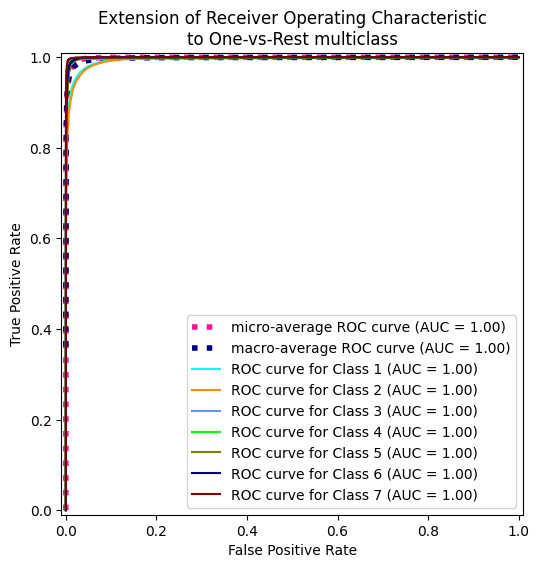

In [21]:
rTree = RandomForestClassifier(random_state = 42, n_jobs = -1, class_weight = "balanced")
pipeline = Pipeline([
    ('scaler', None),
    ('model', rTree)
])
param_grid = {
    "model__n_estimators" : [50, 100],
    "model__criterion" : ["gini", "entropy"],
    "model__max_depth" : [10, 20, 30]
}
# Configurar Grid Search
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="roc_auc_ovr",  # Métrica de evaluación
    cv=StratifiedKFold(5),  # Validación cruzada de 5 folds
    verbose=1
)

start = time.process_time()  # Inicia el contador de CPU time
# Ejecutar Grid Search
grid_search.fit(X_train, y_train)
end = time.process_time()  # Finaliza el contador de CPU time
print(f"CPU Time: {end - start} segundos")

# Mejores hiperparámetros
print("Mejores hiperparámetros:", grid_search.best_params_)

# Evaluar el mejor modelo
best_model_B = grid_search.best_estimator_

metricas(best_model_B)
LAUC_curvas(best_model_B)

In [32]:
# Entrenar modelo
rTree = RandomForestClassifier(random_state = 42, n_estimators = 100, n_jobs = -1, criterion = "entropy", max_depth=30, class_weight='balanced')
start = time.process_time()  # Inicia el contador de CPU time
rTree.fit(X_train, y_train)
end = time.process_time()  # Finaliza el contador de CPU time
print("Accuracy on training set: {:.3f}".format(rTree.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(rTree.score(X_test, y_test)))

print(f"CPU Time: {end - start} segundos")

# Evaluar
y_pred = rTree.predict(X_test)
print(classification_report(y_test, y_pred))

Accuracy on training set: 1.000
Accuracy on test set: 0.958
CPU Time: 166.9745299669994 segundos
              precision    recall  f1-score   support

           1       0.97      0.95      0.96     42557
           2       0.95      0.97      0.96     56500
           3       0.95      0.97      0.96      7121
           4       0.91      0.84      0.87       526
           5       0.92      0.83      0.87      1995
           6       0.93      0.91      0.92      3489
           7       0.97      0.96      0.97      4015

    accuracy                           0.96    116203
   macro avg       0.94      0.92      0.93    116203
weighted avg       0.96      0.96      0.96    116203



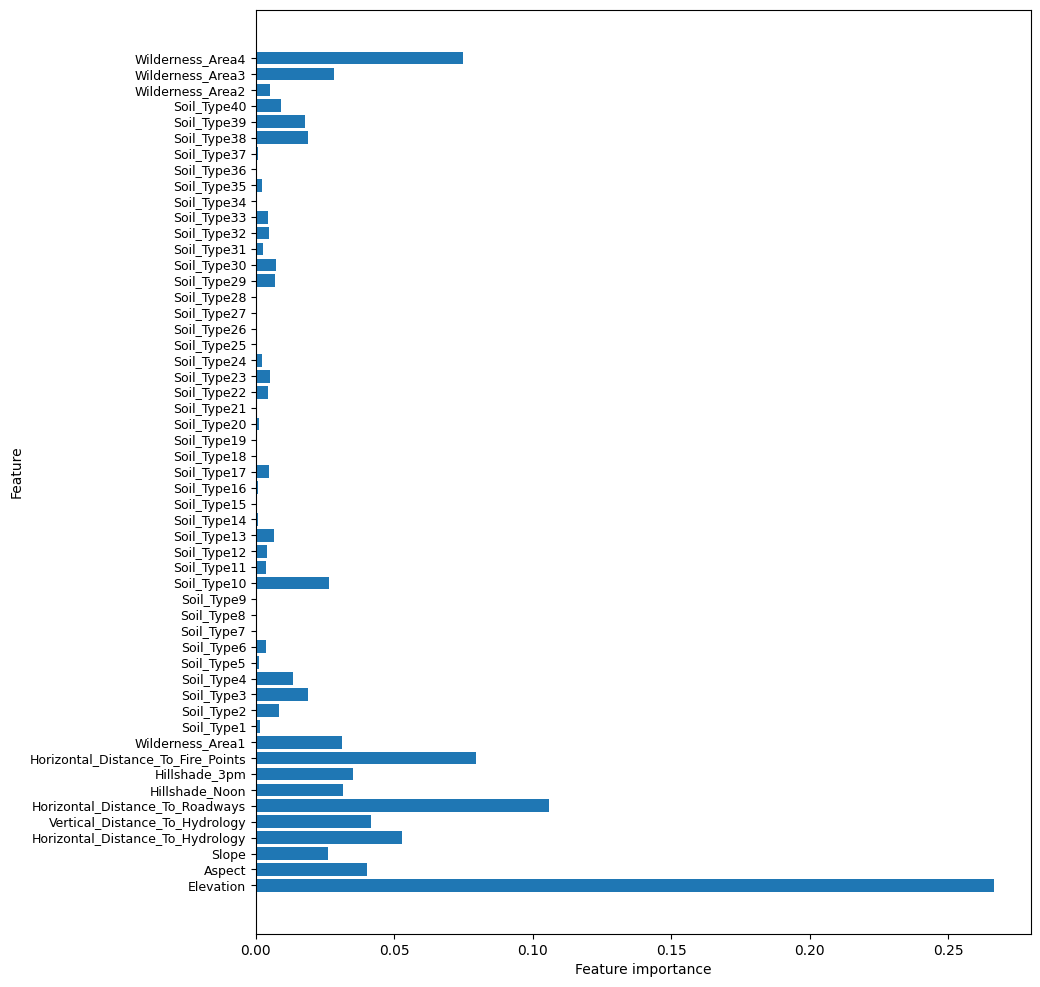

In [34]:
plot_feature_importances(rTree)

## SVM

In [ ]:
from sklearn.svm import SVC
from sklearn.svm import LinearSVC

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer

# 1. Definir el pipeline completo
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Escalado de características
    ('feature_selection', SelectKBest()),  # Selección de características
    ('classifier', LinearSVC(dual=False, random_state=42))  # LinearSVC (dual=False para n_samples > n_features)
])

# 2. Definir el espacio de búsqueda de hiperparámetros
param_grid = {
    'feature_selection__k': ['all'],  # Número de características a seleccionar
    'feature_selection__score_func': [f_classif],  # Función para selección de características
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],  # Parámetro de regularización
    'classifier__penalty': ['l1', 'l2'],  # Tipo de penalización
    'classifier__loss': ['squared_hinge'],  # Función de pérdida
    'classifier__max_iter': [1000]  # Máximo de iteraciones
}

# 4. Configurar GridSearchCV
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="roc_auc_ovr",
    refit='roc_auc_ovr',  # Métrica principal para seleccionar el mejor modelo
    cv=5,  # 5-fold cross-validation
    n_jobs=-1,  # Usar todos los cores disponibles
    verbose=2  # Mostrar progreso detallado
)

# 5. Ejecutar la búsqueda en los datos de entrenamiento
grid_search.fit(X_train, y_train)

# 6. Resultados
print("\nMejores parámetros encontrados:")
print(grid_search.best_params_)

print("\nMejor score de validación cruzada (AUC):")
print(f"{grid_search.best_score_:.4f}")

# 7. Evaluar en el conjunto de prueba
y_pred = grid_search.predict(X_test)
y_decision = grid_search.decision_function(X_test)  # Scores para calcular AUC

print("\nMétricas en conjunto de prueba:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"AUC: {roc_auc_score(y_test, y_decision):.4f}")

# 8. Obtener el mejor modelo
best_model = grid_search.best_estimator_

Fitting 5 folds for each of 12 candidates, totalling 60 fits


KeyboardInterrupt: 

In [ ]:
X_t, X_valid, y_t, y_valid = train_test_split(X_train_sc, y_train, random_state=42)

Precisión: 68.25%
Matriz de confusión:
[[28644  9706    37     0   507   328  3335]
 [11619 39629  1431     3  1723  1833   262]
 [    0   324  5148   169    54  1426     0]
 [    0     0   255   220     0    51     0]
 [   38  1042   185     0   646    84     0]
 [    0   367  1247    68    95  1712     0]
 [  665    20    17     0     0     0  3313]]
Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.70      0.67      0.69     42557
           2       0.78      0.70      0.74     56500
           3       0.62      0.72      0.67      7121
           4       0.48      0.42      0.45       526
           5       0.21      0.32      0.26      1995
           6       0.32      0.49      0.38      3489
           7       0.48      0.83      0.61      4015

    accuracy                           0.68    116203
   macro avg       0.51      0.59      0.54    116203
weighted avg       0.70      0.68      0.69    116203

Micro-averaged One-vs-

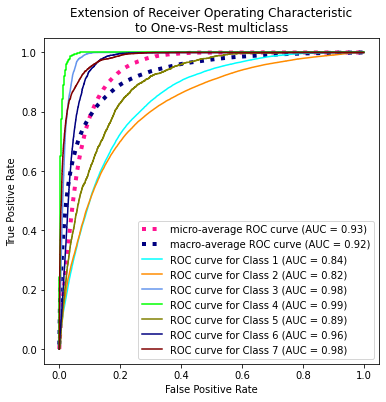

In [ ]:
metricas(Lsvm, scaled = True)
LAUC_curvas(Lsvm, linScv = True)

In [ ]:
X_t_SM, X_valid_SM, y_t_SM, y_valid_SM = train_test_split(X_train_SM_sc, y_train, random_state=42)

In [ ]:
best_score_SM = 0
for C in [0.001, 0.01, 0.1, 1, 10, 100]:
    Lsvm = LinearSVC(C=C)
    Lsvm.fit(X_t, y_t) # Ajuste del modelo SVC
    score = Lsvm.score(X_valid, y_valid) # Score para selección de parámetros
    if score > best_score_B:
        best_score_B = score
        best_parameters_B = {'C': C} # Almacenamos el mejor score y sus parámetros
    print("Modelo terminado")

TypeError: __init__() got an unexpected keyword argument 'train_weight'

In [ ]:
best_score = 0
for C in [0.001, 0.01, 0.1, 1, 10, 100]:
    Lsvm = LinearSVC(C=C)
    Lsvm.fit(X_t, y_t) # Ajuste del modelo SVC
    score = Lsvm.score(X_valid, y_valid) # Score para selección de parámetros
    if score > best_score:
        best_score = score
        best_parameters = {'C': C} # Almacenamos el mejor score y sus parámetros
    print("Modelo terminado")

Modelo terminado
Modelo terminado
Modelo terminado
Modelo terminado
Modelo terminado
Modelo terminado


In [ ]:
print(best_score)
print(best_parameters)

0.7146545269915578
{'C': 1}


In [ ]:
Lsvm = LinearSVC

In [ ]:
svm = SVC(random_state = 42)
param_grid = {
    "gamma": [0.001, 0.01, 0.1, 1, 10, 100],
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
}
# Configurar Grid Search
grid_search = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    scoring="accuracy",  # Métrica de evaluación
    cv=5,  # Validación cruzada de 5 folds
    n_jobs=-1,  # Usar todos los núcleos de la CPU
)
start = time.process_time()  # Inicia el contador de CPU time
# Ejecutar Grid Search
grid_search.fit(X_train, y_train)
end = time.process_time()  # Finaliza el contador de CPU time
print(f"CPU Time: {end - start} segundos")

# Mejores hiperparámetros
print("Mejores hiperparámetros:", grid_search.best_params_)

# Evaluar el mejor modelo
best_model = grid_search.best_estimator_

metricas(best_model)
LAUC_curvas(best_model)

## XgBoost

In [20]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

In [48]:
le = LabelEncoder()
le_y_train = le.fit_transform(y_train)
le_y_test = le.transform(y_test)
le_y_train_SM = le.fit_transform(y_train_SM)
le_y_train_ADA = le.transform(y_train_ADA)

In [51]:
xgb = XGBClassifier(random_state=42, tree_method='gpu_hist', use_label_encoder=False, verbosity=2)

pipeline = Pipeline([
    ('scaler', None),  # Escalado de características
    ('xgb', xgb),  # Selección de características
])

param_grid = {
    'xgb__n_estimators': [50, 100],
    'xgb__max_depth':[6, 7, 8],
    'xgb__learning_rate': [0.1, 0.2, 0.3]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='roc_auc_ovr',
    cv=StratifiedKFold(5),
    n_jobs=-1,
    verbose=2
)

In [52]:
grid_search.fit(X_train, le_y_train)

# Mejores hiperparámetros
print("Mejores hiperparámetros:", grid_search.best_params_)

# Evaluar el mejor modelo
best_model = grid_search.best_estimator_

metricas(best_model)
LAUC_curvas(best_model)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


KeyboardInterrupt: 

Precisión: 86.71%
Matriz de confusión:
[[35667  6621     2     0    15     6   246]
 [ 5426 50584   202     0   111   152    25]
 [    2   266  6500    32     1   320     0]
 [    0     0    54   454     0    18     0]
 [   26   803    31     0  1124    11     0]
 [    1   213   459    16     1  2799     0]
 [  363    18     0     0     0     0  3634]]
Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.86      0.84      0.85     42557
           1       0.86      0.90      0.88     56500
           2       0.90      0.91      0.90      7121
           3       0.90      0.86      0.88       526
           4       0.90      0.56      0.69      1995
           5       0.85      0.80      0.82      3489
           6       0.93      0.91      0.92      4015

    accuracy                           0.87    116203
   macro avg       0.89      0.83      0.85    116203
weighted avg       0.87      0.87      0.87    116203

Micro-averaged One-vs-

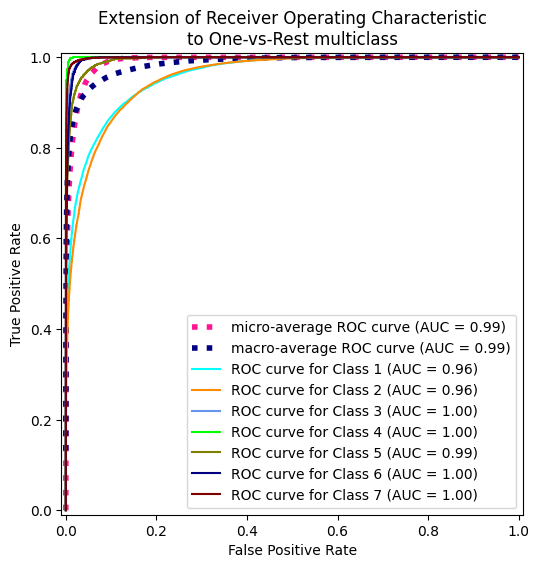

In [28]:
xgb.fit(X_train, le_y_train)

metricas(xgb)
LAUC_curvas(xgb)